## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/online_retail_clean.csv")
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

df.head()

,invoice_no,stockcode,description,quantity,invoice_date,unit_price,customer_id,country,source_sheet,is_cancellation,sales_amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010,False,30.0


## Defini a reference date

In [2]:
# Ususly we use the next day of last day in data
snapshot_date = df["invoice_date"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

## 计算基础RFM表

In [3]:
rfm = (
    df.groupby("customer_id")
    .agg(
        recency=("invoice_date", lambda x: (snapshot_date - x.max()).days),
        frequency=("invoice_no", "nunique"),
        monetary=("sales_amount", "sum")
    )
    .reset_index()
)

rfm.head()

,customer_id,recency,frequency,monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [4]:
rfm.describe()

,customer_id,recency,frequency,monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


## RFM 分布

Recency 分布

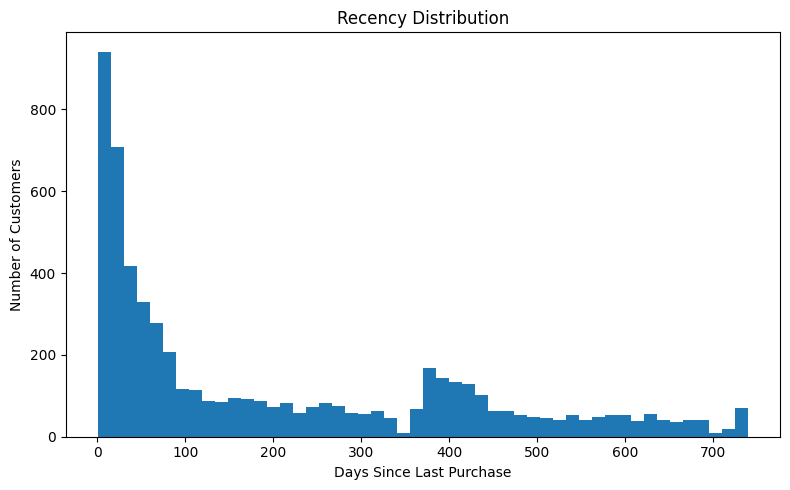

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(rfm["recency"], bins=50)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Frequency 分布

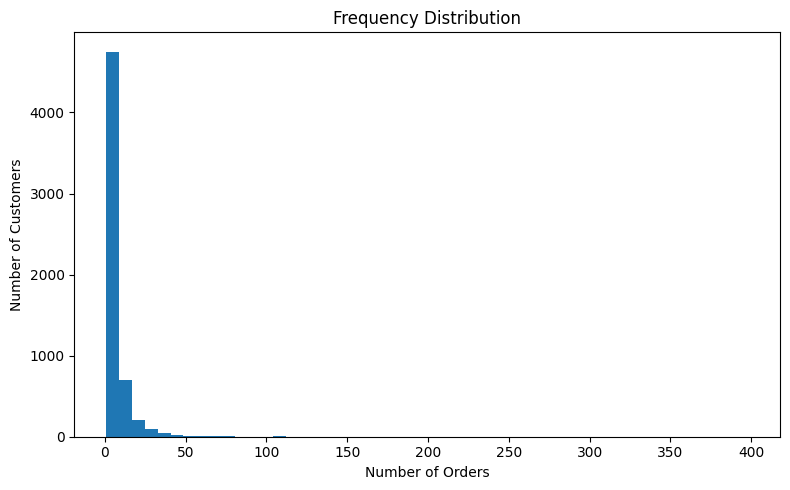

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(rfm["frequency"], bins=50)
plt.title("Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Monetary 分布

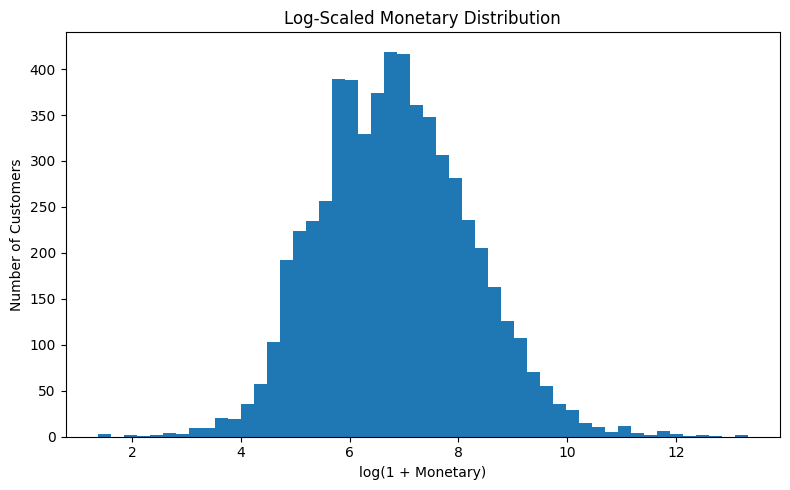

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(rfm["monetary"]), bins=50)
plt.title("Log-Scaled Monetary Distribution")
plt.xlabel("log(1 + Monetary)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 给RFM打分

In [9]:
def r_score(x, col, quantiles):
    # Recency 越小越好
    if x <= quantiles[col][0.2]:
        return 5
    elif x <= quantiles[col][0.4]:
        return 4
    elif x <= quantiles[col][0.6]:
        return 3
    elif x <= quantiles[col][0.8]:
        return 2
    else:
        return 1

def fm_score(x, col, quantiles):
    # Frequency 越大越好
    # Monetary 越大越好
    if x <= quantiles[col][0.2]:
        return 1
    elif x <= quantiles[col][0.4]:
        return 2
    elif x <= quantiles[col][0.6]:
        return 3
    elif x <= quantiles[col][0.8]:
        return 4
    else:
        return 5

计算分位点：

In [10]:
quantiles = rfm[["recency", "frequency", "monetary"]].quantile([0.2, 0.4, 0.6, 0.8]).to_dict()
quantiles

{'recency': {0.2: 19.0, 0.4: 59.0, 0.6: 189.0, 0.8: 410.0},
 'frequency': {0.2: 1.0, 0.4: 2.0, 0.6: 4.0, 0.8: 8.0},
 'monetary': {0.2: 291.278,
  0.4: 618.234,
  0.6: 1248.538,
  0.8: 2966.6860000000056}}

In [11]:
rfm["r_score"] = rfm["recency"].apply(r_score, args=("recency", quantiles))
rfm["f_score"] = rfm["frequency"].apply(fm_score, args=("frequency", quantiles))
rfm["m_score"] = rfm["monetary"].apply(fm_score, args=("monetary", quantiles))

rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score
0,12346.0,326,12,77556.46,2,5,5
1,12347.0,2,8,5633.32,5,4,5
2,12348.0,75,5,2019.40,3,4,4
3,12349.0,19,4,4428.69,5,3,5
4,12350.0,310,1,334.40,2,1,2


In [12]:
rfm["rfm_score"] = (
    rfm["r_score"].astype(str) +
    rfm["f_score"].astype(str) +
    rfm["m_score"].astype(str)
)

rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,5633.32,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212


总分：

In [13]:
rfm["rfm_total_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]
rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score
0,12346.0,326,12,77556.46,2,5,5,255,12
1,12347.0,2,8,5633.32,5,4,5,545,14
2,12348.0,75,5,2019.40,3,4,4,344,11
3,12349.0,19,4,4428.69,5,3,5,535,13
4,12350.0,310,1,334.40,2,1,2,212,5


## segment label

In [14]:
def assign_segment(row):
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 4:
        return "Loyal Customers"
    elif r >= 4 and f >= 2 and m >= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Hibernating"
    else:
        return "Others"

In [15]:
rfm["segment"] = rfm.apply(assign_segment, axis=1)
rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score,segment
0,12346.0,326,12,77556.46,2,5,5,255,12,At Risk
1,12347.0,2,8,5633.32,5,4,5,545,14,Champions
2,12348.0,75,5,2019.40,3,4,4,344,11,Loyal Customers
3,12349.0,19,4,4428.69,5,3,5,535,13,Potential Loyalists
4,12350.0,310,1,334.40,2,1,2,212,5,Hibernating


各segment数量

In [16]:
rfm["segment"].value_counts()

segment
Others                 1409
Hibernating            1359
Champions              1277
Potential Loyalists     650
Loyal Customers         601
At Risk                 582
Name: count, dtype: int64

看比例：

In [17]:
rfm["segment"].value_counts(normalize=True)

segment
Others                 0.239707
Hibernating            0.231201
Champions              0.217251
Potential Loyalists    0.110582
Loyal Customers        0.102246
At Risk                0.099013
Name: proportion, dtype: float64

## Segment summary

In [18]:
segment_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        customer_count=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        median_monetary=("monetary", "median")
    )
    .sort_values("avg_monetary", ascending=False)
)

segment_summary

,segment,customer_count,avg_recency,avg_frequency,avg_monetary,median_monetary
1,Champions,1277,19.850431,17.324980,9464.554820,4103.120
3,Loyal Customers,601,86.630616,8.327787,2975.617879,1916.110
0,At Risk,582,355.462199,5.826460,2590.877426,1362.440
5,Potential Loyalists,650,25.400000,2.936923,1332.924540,815.245
4,Others,1409,178.600426,2.029099,806.337547,545.170
2,Hibernating,1359,464.295806,1.236939,263.741804,239.460


客户占比：

In [19]:
segment_summary["customer_pct"] = segment_summary["customer_count"] / segment_summary["customer_count"].sum()
segment_summary

,segment,customer_count,avg_recency,avg_frequency,avg_monetary,median_monetary,customer_pct
1,Champions,1277,19.850431,17.324980,9464.554820,4103.120,0.217251
3,Loyal Customers,601,86.630616,8.327787,2975.617879,1916.110,0.102246
0,At Risk,582,355.462199,5.826460,2590.877426,1362.440,0.099013
5,Potential Loyalists,650,25.400000,2.936923,1332.924540,815.245,0.110582
4,Others,1409,178.600426,2.029099,806.337547,545.170,0.239707
2,Hibernating,1359,464.295806,1.236939,263.741804,239.460,0.231201


## 把segment和原始销售关联，算每个segment的revenue share

In [20]:
segment_revenue = (
    rfm.groupby("segment", as_index=False)
    .agg(
        customer_count=("customer_id", "count"),
        total_revenue=("monetary", "sum"),
        avg_revenue=("monetary", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

segment_revenue["revenue_pct"] = segment_revenue["total_revenue"] / segment_revenue["total_revenue"].sum()
segment_revenue

,segment,customer_count,total_revenue,avg_revenue,revenue_pct
1,Champions,1277,1.208624e+07,9464.554820,0.681167
3,Loyal Customers,601,1.788346e+06,2975.617879,0.100789
0,At Risk,582,1.507891e+06,2590.877426,0.084983
4,Others,1409,1.136130e+06,806.337547,0.064031
5,Potential Loyalists,650,8.664010e+05,1332.924540,0.048829
2,Hibernating,1359,3.584251e+05,263.741804,0.020200


## Figures

segment customer count

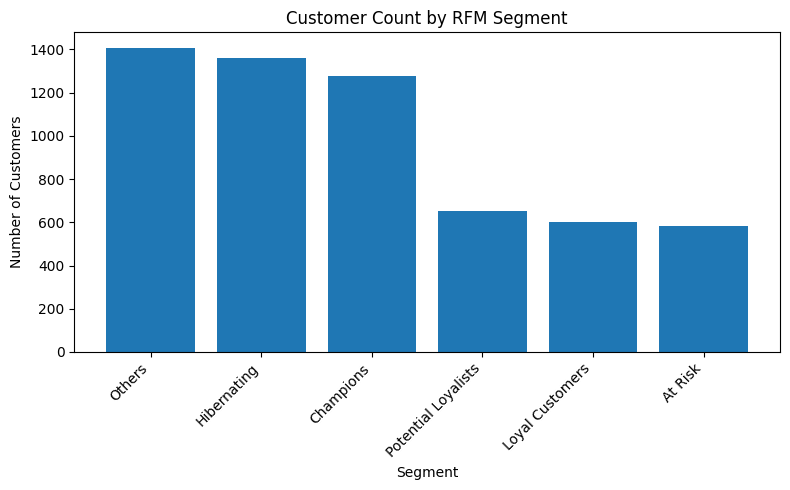

In [21]:
segment_counts = rfm["segment"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Customer Count by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

segment average monetary

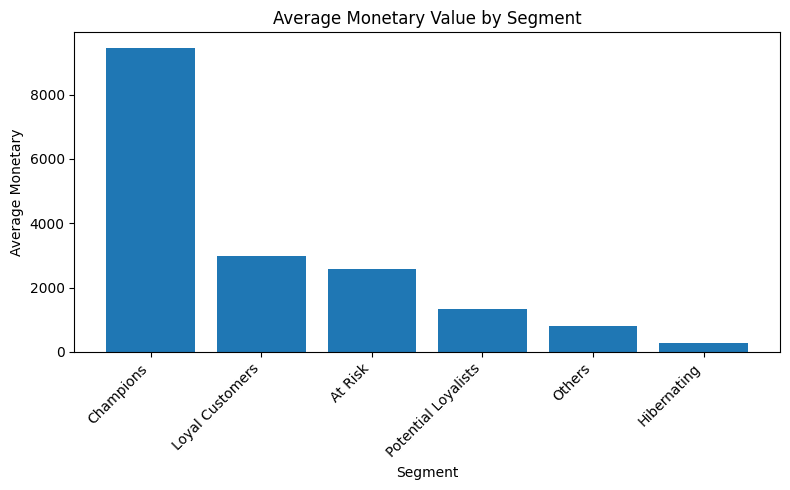

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(segment_summary["segment"], segment_summary["avg_monetary"])
plt.xticks(rotation=45, ha="right")
plt.title("Average Monetary Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Monetary")
plt.tight_layout()
plt.show()

segment revenue share

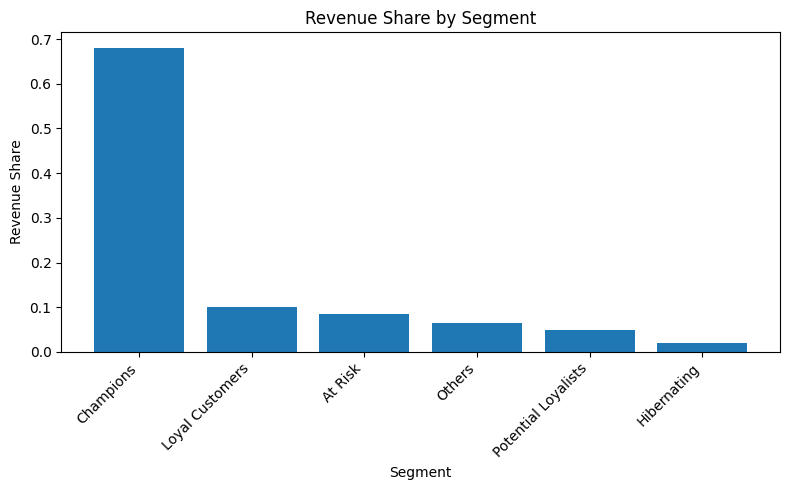

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(segment_revenue["segment"], segment_revenue["revenue_pct"])
plt.xticks(rotation=45, ha="right")
plt.title("Revenue Share by Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue Share")
plt.tight_layout()
plt.show()

In [24]:
rfm.to_csv("../data/processed/customer_rfm.csv", index=False)
segment_summary.to_csv("../outputs/tables/rfm_segment_summary.csv", index=False)
segment_revenue.to_csv("../outputs/tables/rfm_segment_revenue.csv", index=False)

## RFM segmentation insights

1. The customer base is heterogeneous in recency, frequency, and monetary value, confirming that segmentation is necessary for targeted personalization.
2. “Champions” and “Loyal Customers” are likely to contribute disproportionately to revenue and should be prioritized for retention, premium recommendation, and early-access campaigns.
3. “Potential Loyalists” represent an important growth segment that may respond well to onboarding sequences, repeat-purchase nudges, and personalized cross-sell recommendations.
4. “At Risk” customers have shown meaningful historical value but weaker recent activity, making them suitable for win-back campaigns and reactivation experiments.
5. “Hibernating” and lower-value segments may require lighter-touch, cost-efficient targeting rather than high-investment personalization.

## RFM segmentation conclusion

The segmentation results show that a small number of high-value customers drive a disproportionate share of revenue, while other groups differ meaningfully in recency and repeat-purchase behavior. This supports a tiered personalization strategy in which recommendation intensity, retention investment, and reactivation tactics are adapted to customer value and engagement level.

## Action mapping

In [25]:
segment_actions = pd.DataFrame({
    "segment": [
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "At Risk",
        "Hibernating",
        "Others"
    ],
    "recommended_action": [
        "Prioritize premium recommendations and loyalty rewards",
        "Encourage repeat purchases and bundle offers",
        "Use personalized follow-up and cross-sell campaigns",
        "Run win-back promotions and reactivation tests",
        "Apply low-cost remarketing or exclude from expensive targeting",
        "Use generic baseline recommendation strategies"
    ]
})

segment_actions

,segment,recommended_action
0,Champions,Prioritize premium recommendations and loyalty...
1,Loyal Customers,Encourage repeat purchases and bundle offers
2,Potential Loyalists,Use personalized follow-up and cross-sell camp...
3,At Risk,Run win-back promotions and reactivation tests
4,Hibernating,Apply low-cost remarketing or exclude from exp...
5,Others,Use generic baseline recommendation strategies


In [26]:
segment_actions.to_csv("../outputs/tables/rfm_segment_actions.csv", index=False)